In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from functions import *
from scipy.linalg import toeplitz

plt.rcParams.update({'font.size': 12})

In [11]:
# Read the file with space-separated values using regex to match multiple spaces
wolf = pd.read_csv("data/Wolf_number.dat", delimiter=r'\s+', names=['Year', 'Month', 'Value'])

# Check the data
print(wolf.head())

   Year  Month  Value
0  1749      1   58.0
1  1749      2   62.6
2  1749      3   70.0
3  1749      4   55.7
4  1749      5   85.0


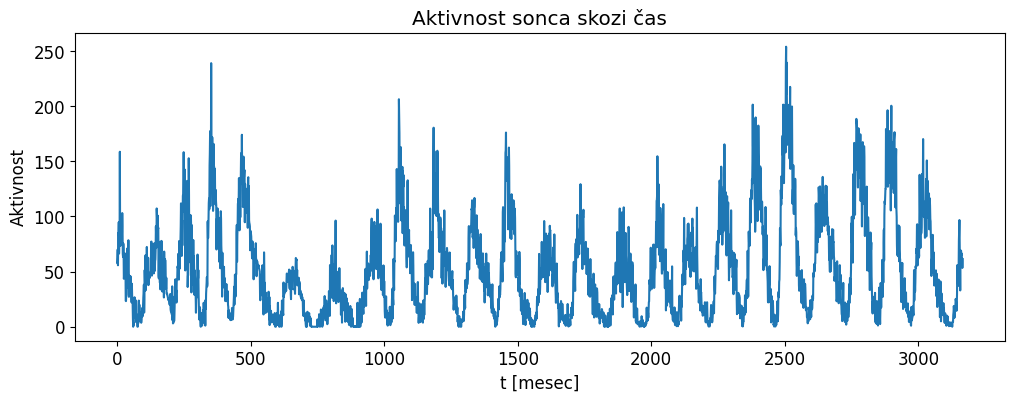

In [12]:
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Aktivnost sonca skozi čas')
ax.set_ylabel('Aktivnost')
ax.set_xlabel('t [mesec]')
ax.plot(wolf.index, wolf['Value'])

In [13]:
learn = 2500
pred = len(wolf) - learn
half = int(len(wolf)/2)
# wolf_fit = wolf['Value'].diff().dropna().values[:learn]
wolf_fit = wolf['Value'].values[:learn]
avg = np.average(wolf_fit)
wolf_fit = wolf_fit - avg

poles10, poles_adjusted10, prediction10 = predict(wolf_fit, 10, pred, 'Reflect')
poles50, poles_adjusted50, prediction50 = predict(wolf_fit, 50, pred, 'Reflect')
poles100, poles_adjusted100, prediction100 = predict(wolf_fit, 100, pred, 'Reflect')
poles500, poles_adjusted500, prediction500 = predict(wolf_fit, 500, pred, 'Reflect')
poles1000, poles_adjusted1000, prediction1000 = predict(wolf_fit, 1000, pred, 'Reflect')
poles1300, poles_adjusted1300, prediction1300 = predict(wolf_fit, 1300, pred, 'Reflect')

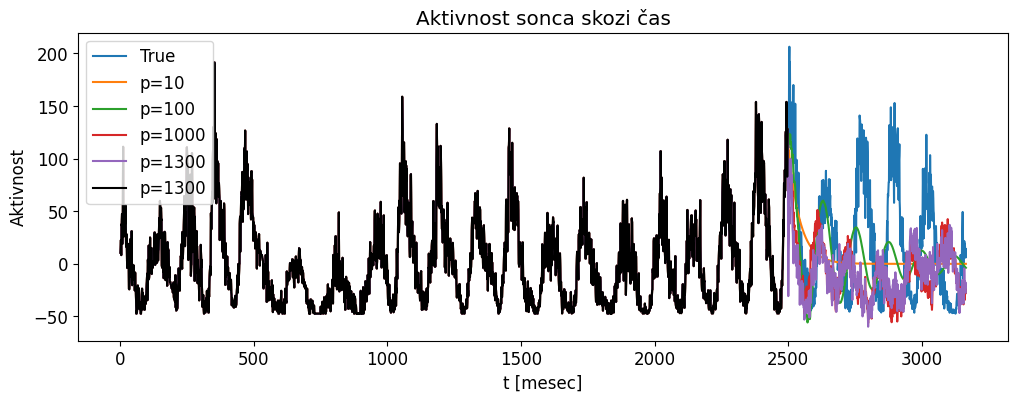

In [14]:
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Aktivnost sonca skozi čas')
ax.set_ylabel('Aktivnost')
ax.set_xlabel('t [mesec]')
ax.plot(wolf.index, wolf['Value'] - avg, label='True')
ax.plot(wolf.index, prediction10, label='p=10')
ax.plot(wolf.index, prediction100, label='p=100')
ax.plot(wolf.index, prediction1000, label='p=1000')
ax.plot(wolf.index, prediction1300, label='p=1300')
ax.plot(wolf.index[:learn], prediction1300[:learn], label='p=1300', color='black')
ax.legend(loc='upper left')

In [15]:
learn = 2500
pred = len(wolf) - learn
half = int(len(wolf)/2)
wolf_fit = wolf['Value'].diff().dropna().values[:learn]

poles10, poles_adjusted10, prediction10 = predict(wolf_fit, 10, pred, 'Reflect')
poles50, poles_adjusted50, prediction50 = predict(wolf_fit, 50, pred, 'Reflect')
poles100, poles_adjusted100, prediction100 = predict(wolf_fit, 100, pred, 'Reflect')
poles500, poles_adjusted500, prediction500 = predict(wolf_fit, 500, pred, 'Reflect')
poles1000, poles_adjusted1000, prediction1000 = predict(wolf_fit, 1000, pred, 'Reflect')
poles1300, poles_adjusted1300, prediction1300 = predict(wolf_fit, 1300, pred, 'Reflect')

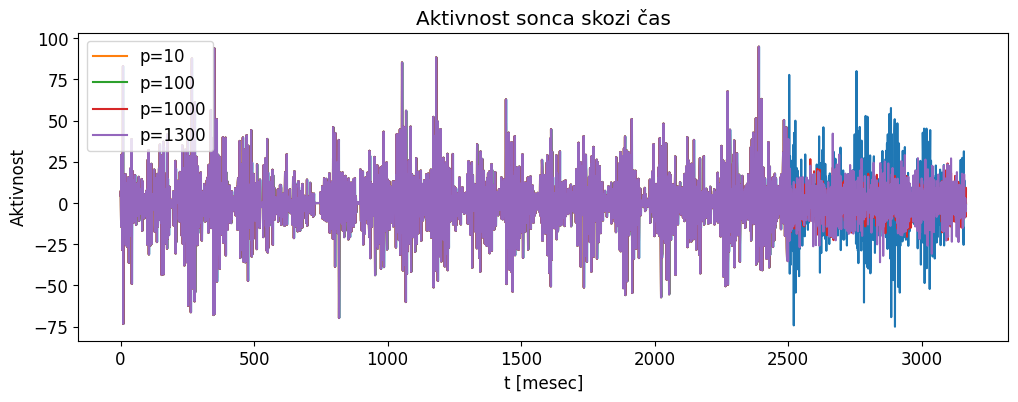

In [16]:
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Aktivnost sonca skozi čas')
ax.set_ylabel('Aktivnost')
ax.set_xlabel('t [mesec]')
ax.plot(wolf.index, wolf['Value'].diff())
ax.plot(wolf.index, prediction10, label='p=10')
# ax.plot(wolf.index, prediction50)
ax.plot(wolf.index, prediction100, label='p=100')
# ax.plot(wolf.index, prediction500)
ax.plot(wolf.index, prediction1000, label='p=1000')
ax.plot(wolf.index, prediction1300, label='p=1300')
ax.legend(loc='upper left')

C:\Users\Tadej\AppData\Local\Temp\ipykernel_1844\2463124056.py:4: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  S = cumtrapz(prediction1300, wolf.index, initial=0)


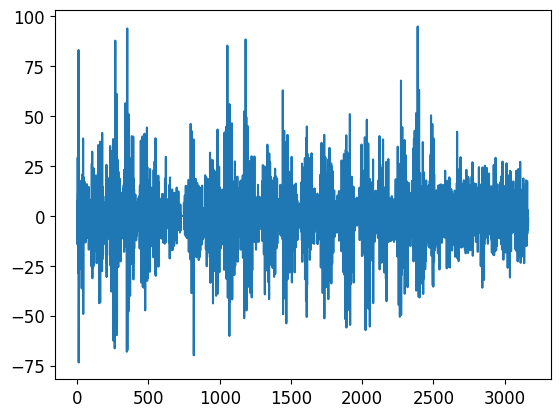

In [17]:
import numpy as np
from scipy.integrate import cumtrapz

S = cumtrapz(prediction1300, wolf.index, initial=0)

plt.plot(wolf.index, prediction1300)